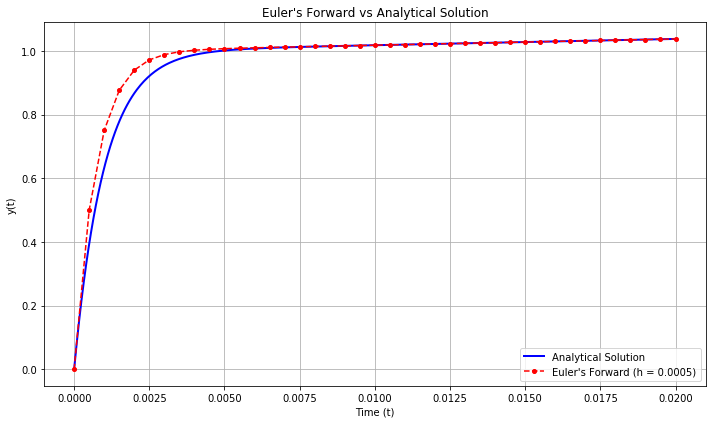

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation
def dy_dt(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)

# Define the analytical solution
def exact_solution(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

# Parameters
t_start = 0
t_end = 0.02    # Short time interval to capture the fast transient change
h = 0.0005      # Step size must be < 0.002 for stability due to the -1000y term
y_0 = 0         # Initial condition y(0) = 0

# 1. Compute Euler's Forward Method
t_euler = np.arange(t_start, t_end + h, h)
y_euler = np.zeros(len(t_euler))
y_euler[0] = y_0

for i in range(1, len(t_euler)):
    t_n = t_euler[i-1]
    y_n = y_euler[i-1]
    # Euler Update: y_{n+1} = y_n + h * f(t_n, y_n)
    y_euler[i] = y_n + h * dy_dt(t_n, y_n)

# 2. Compute Analytical Solution for comparison
t_exact = np.linspace(t_start, t_end, 500)
y_exact = exact_solution(t_exact)

# 3. Plot the results
plt.figure(figsize=(10, 6))

# Plot analytical solution as a smooth continuous line
plt.plot(t_exact, y_exact, label='Analytical Solution', color='blue', linewidth=2)

# Plot Euler's approximation as dashed lines with markers
plt.plot(t_euler, y_euler, label=f"Euler's Forward (h = {h})", 
         color='red', linestyle='--', marker='o', markersize=4)

# Format the canvas
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title("Euler's Forward vs Analytical Solution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()